In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

from csan import (
    make_synth_blocks,
    build_local_pool_matrix_from_grid,
    validity_first_backtest,
    load_eobs_rr,
    eobs_to_blocks,
    basic_X_diagnostics)


### Import data

In [2]:
X_np, years, grid_shape, peer_coords = make_synth_blocks(
    B=400, grid_shape=(12,12),
    p_event=.25, p_hit_given_event=.5,
    severity="pareto", pareto_alpha=1.8, pareto_scale=1.0,
    heterogeneity=.8,
    spatial_factor_strength=0.8,
    common_factor_strength=0.3,
    seed=0,
)

print(X_np.shape, years.min(), years.max(), grid_shape, peer_coords.shape)

hit_rate_per_peer = (X_np > 0).mean(axis=0)      # length n
print("avg peer hit rate:", hit_rate_per_peer.mean())
print("min/median/max peer hit rate:", hit_rate_per_peer.min(),
      np.median(hit_rate_per_peer), hit_rate_per_peer.max())

(400, 144) 1950 2349 (12, 12) (144, 2)
avg peer hit rate: 0.13597222222222222
min/median/max peer hit rate: 0.0375 0.1325 0.2375


### Set model parameters

In [3]:
delta=0.1
eta=0.0
eps=0.2

### Split mode: time

=== Validity-first backtest (updated) ===
Pooling: global-uniform
Mode: time | Splits: 12 | nTest=25 | nC=100
Nominal coverage: 0.900
PASS rate: 1.000

Split-level mean coverage across peers (not theorem-aligned, but intuitive):
  candidate : mean=0.910, std=0.035
  operational: mean=0.910, std=0.035
  identity  : mean=0.911, std=0.035

Worst-peer shortfall from nominal (theorem-aligned empirical):
  candidate   : worst=0.870 (shortfall=0.030), p05=0.884 (shortfall=0.016)
  operational : worst=0.870 (shortfall=0.030), p05=0.884 (shortfall=0.016)
  identity    : worst=0.877 (shortfall=0.023), p05=0.884 (shortfall=0.016)

Certified cap efficiency (lower is better):
  mean <w,c0> (identity)     : 1.16 ± 0.0747
  mean <w,c*> (candidate)    : 1.13 ± 0.103
  mean <w,c_op> (operational): 1.13 ± 0.103
  AggCapRatio candidate      : 0.978 ± 0.073
  AggCapRatio operational    : 0.978 ± 0.073

Additional certified utility metrics (lower ratios are better):
  Top10 cap ratio (candidate)   : 0.946 

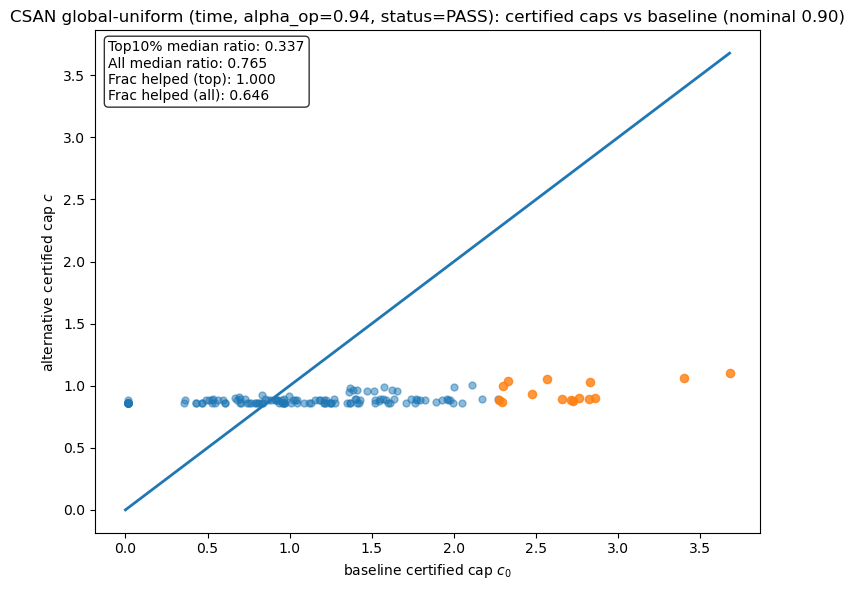

In [4]:
bt_time = validity_first_backtest(
    X_np=X_np, years=years,
    delta=delta, eta=eta, eps=eps,
    alphas=np.linspace(0,1,51, dtype=np.float32),
    nT=100, nV=60, nC=100, nTest=25,
    step=10,
    split_mode="time",
    make_plots=False,
    W_local=None,
    relief_scatter=True,
    relief_scatter_pick = "first_pass",  # "first_pass" | "median_top10" | "best_top10"
)


### Split mode: random

=== Validity-first backtest (updated) ===
Pooling: global-uniform
Mode: random | Splits: 100 | nTest=20 | nC=100
Nominal coverage: 0.900
PASS rate: 0.770

Split-level mean coverage across peers (not theorem-aligned, but intuitive):
  candidate : mean=0.908, std=0.051
  operational: mean=0.910, std=0.045
  identity  : mean=0.910, std=0.040

Worst-peer shortfall from nominal (theorem-aligned empirical):
  candidate   : worst=0.895 (shortfall=0.005), p05=0.900 (shortfall=0.000)
  operational : worst=0.894 (shortfall=0.006), p05=0.900 (shortfall=0.000)
  identity    : worst=0.895 (shortfall=0.005), p05=0.899 (shortfall=0.001)

Certified cap efficiency (lower is better):
  mean <w,c0> (identity)     : 1.04 ± 0.201
  mean <w,c*> (candidate)    : 0.991 ± 0.184
  mean <w,c_op> (operational): 1 ± 0.19
  AggCapRatio candidate      : 0.967 ± 0.110
  AggCapRatio operational    : 0.970 ± 0.070

Additional certified utility metrics (lower ratios are better):
  Top10 cap ratio (candidate)   : 0.778 ±

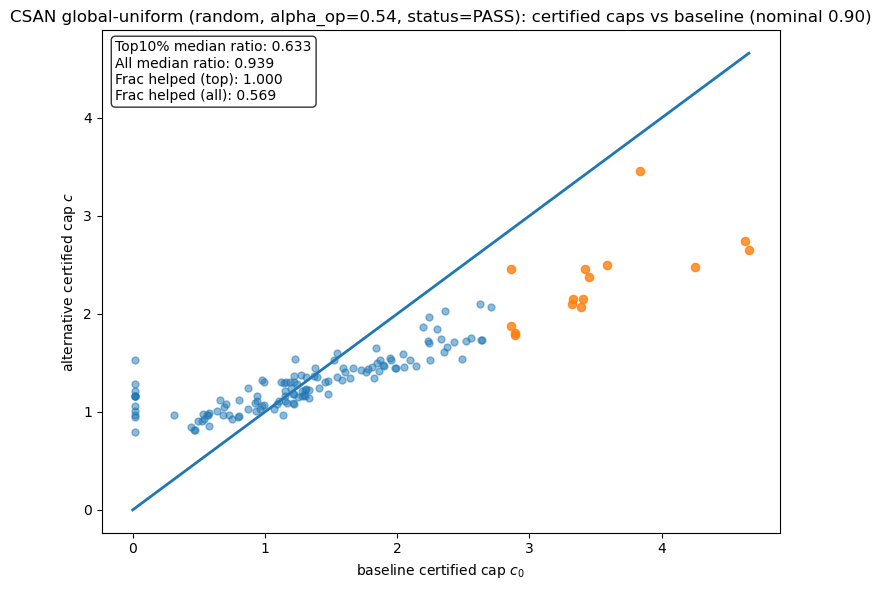

In [5]:
bt_rand = validity_first_backtest(
    X_np=X_np, years=years,
    delta=delta, eta=eta, eps=eps,
    alphas=np.linspace(0,1,51, dtype=np.float32),
    nT=120, nV=40, nC=100, nTest=20,
    split_mode="random",
    n_splits=100,
    seed=0,
    make_plots=False,
    relief_scatter=True,
    relief_scatter_pick = "first_pass",  # "first_pass" | "median_top10" | "best_top10"
)

In [6]:
from csan import print_latex_row, print_latex_identity_row
# ============================================================
# In the GLOBAL notebook, run:
# ============================================================
print("% Random splits")
print_latex_row(bt_rand, "Global")
print_latex_identity_row(bt_rand)

print("% Time splits")
print_latex_row(bt_time, "Global")
print_latex_identity_row(bt_time)


% Random splits
Global & 0.77 & 0.14\tiny$\pm$0.29 & 0.910 (0.900) & 0.970\tiny$\pm$0.070 & 0.907\tiny$\pm$0.198 \\
Identity & -- & 0 & 0.910 (0.899) & -- & -- \\
% Time splits
Global & 1.00 & 0.08\tiny$\pm$0.26 & 0.910 (0.884) & 0.978\tiny$\pm$0.073 & 0.946\tiny$\pm$0.179 \\
Identity & -- & 0 & 0.911 (0.884) & -- & -- \\
